In [1]:
#import pandas as pd
#df = pd.read_csv("consolidated_traffic_data.csv")
#print(df.head())

import pandas as pd
import numpy as np
import json

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

with open('../data/processed/label_mapping.json') as f:
    label_mapping = json.load(f)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Label mapping:", label_mapping)

Train shape: (47764, 23)
Test shape: (11942, 23)
Label mapping: {'BROWSING': 0, 'CHAT': 1, 'FT': 2, 'MAIL': 3, 'P2P': 4, 'STREAMING': 5, 'VOIP': 6, 'VPN-BROWSING': 7, 'VPN-CHAT': 8, 'VPN-FT': 9, 'VPN-MAIL': 10, 'VPN-P2P': 11, 'VPN-STREAMING': 12, 'VPN-VOIP': 13}


In [2]:
#XGBoost Model Build

In [3]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(label_mapping),
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [4]:
#Model Accuracy

In [5]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy)

# Get class names in the correct index order
target_names = [name for name, idx in sorted(label_mapping.items(), key=lambda x: x[1])]

print(classification_report(y_test, y_pred, target_names=target_names))

XGBoost Accuracy: 0.864344330932842
               precision    recall  f1-score   support

     BROWSING       0.88      0.90      0.89      2000
         CHAT       0.80      0.78      0.79       501
           FT       0.90      0.69      0.78       795
         MAIL       0.85      0.73      0.78       273
          P2P       0.91      0.97      0.94       800
    STREAMING       0.93      0.69      0.79       257
         VOIP       0.99      0.96      0.97      1297
 VPN-BROWSING       0.83      0.91      0.86      2000
     VPN-CHAT       0.80      0.65      0.72       568
       VPN-FT       0.83      0.77      0.80       941
     VPN-MAIL       0.86      0.93      0.89       489
      VPN-P2P       0.66      0.86      0.75       683
VPN-STREAMING       0.94      0.91      0.92       223
     VPN-VOIP       0.95      0.93      0.94      1115

     accuracy                           0.86     11942
    macro avg       0.87      0.83      0.85     11942
 weighted avg       0.87   

In [6]:
#TreeSHAP Apply

In [7]:
import sys
print(sys.executable)

C:\Users\LOQ\anaconda3\envs\traffic-classifier\python.exe


In [8]:
import shap
print(shap.__version__)

C:\Users\LOQ\anaconda3\envs\traffic-classifier\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.49.1


In [9]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print("TreeSHAP values calculated successfully!")

TreeSHAP values calculated successfully!


In [10]:
#SHAP Summary SHAP Summary Plot

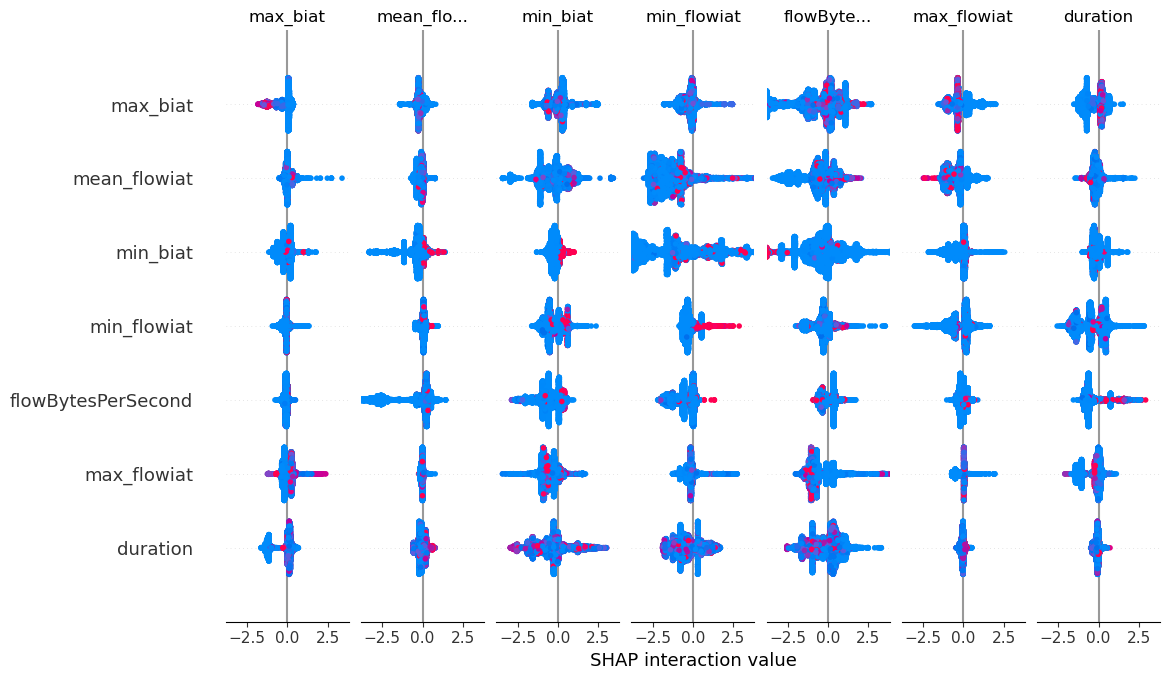

In [11]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

In [12]:
#Feature Importance

In [13]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

               Feature  Importance
16         mean_active    0.068812
14         std_flowiat    0.066876
11         min_flowiat    0.060838
13        mean_flowiat    0.055703
12         max_flowiat    0.054568
8            mean_biat    0.052990
4             min_biat    0.051586
2           total_biat    0.051207
1           total_fiat    0.050274
6             max_biat    0.047844
5             max_fiat    0.047577
9    flowPktsPerSecond    0.047158
17          max_active    0.040105
7            mean_fiat    0.037883
0             duration    0.037290
22            std_idle    0.036611
3             min_fiat    0.034474
10  flowBytesPerSecond    0.033369
20           mean_idle    0.031130
21            max_idle    0.028839
19            min_idle    0.025506
18          std_active    0.022780
15          min_active    0.016580


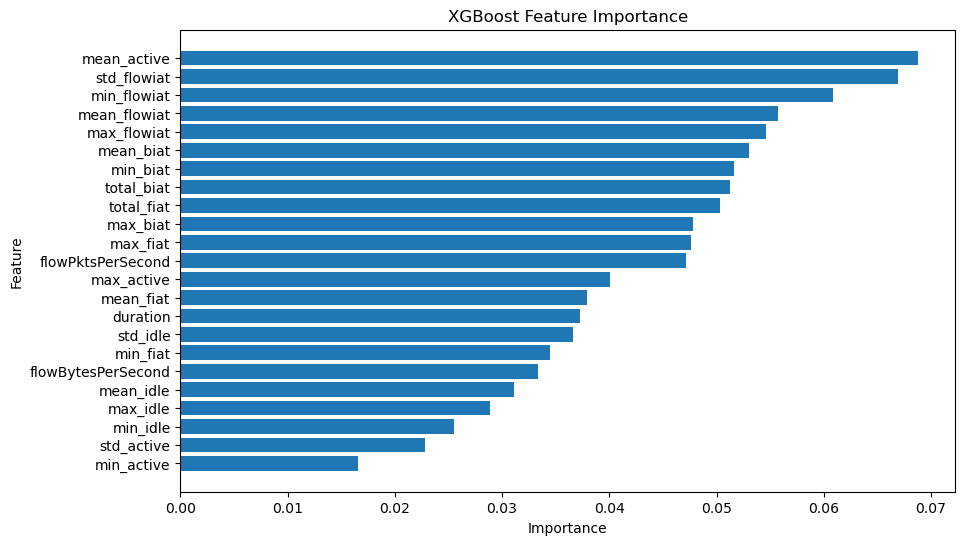

In [14]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [15]:
import joblib
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
print("Model saved successfully.")

Model saved successfully.


TreeSHAP values calculated successfully!


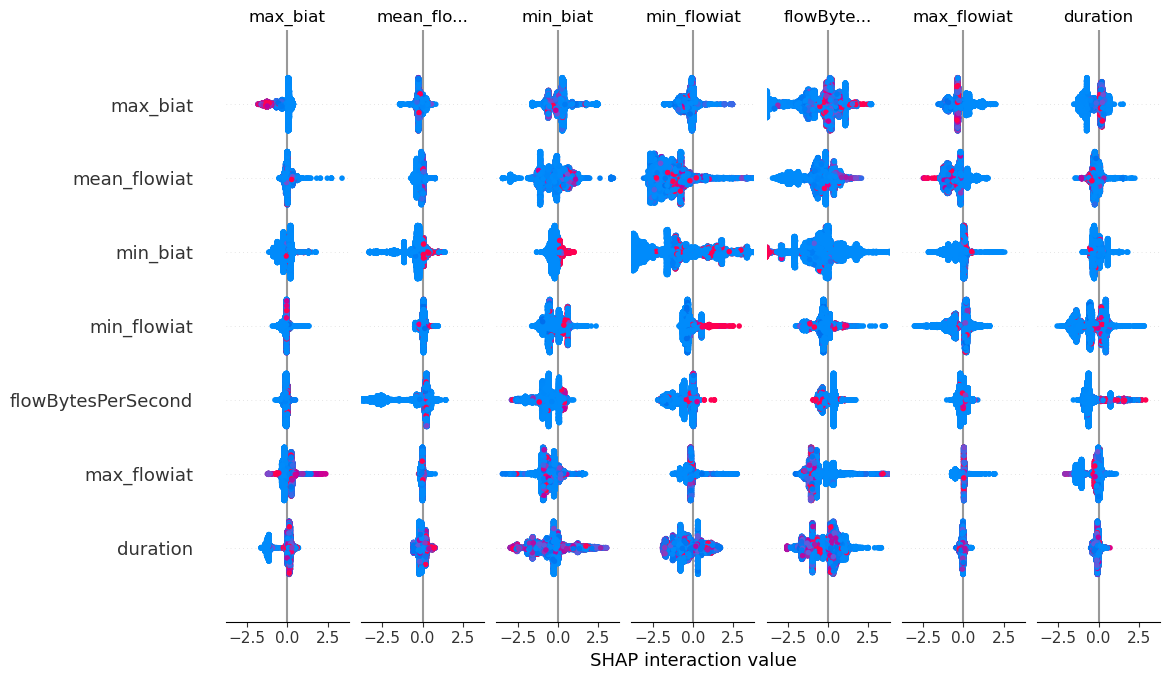

In [16]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print("TreeSHAP values calculated successfully!")

shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

In [17]:
print(feature_importance.head(10))

         Feature  Importance
16   mean_active    0.068812
14   std_flowiat    0.066876
11   min_flowiat    0.060838
13  mean_flowiat    0.055703
12   max_flowiat    0.054568
8      mean_biat    0.052990
4       min_biat    0.051586
2     total_biat    0.051207
1     total_fiat    0.050274
6       max_biat    0.047844
